## Generate Maps of Daily/2-Day Accumulated Precipitation during Storm Hans for 5 most severly affected catchments

### Helper Cell: New Definitions, new Paths

In [1]:
#[Setup, imports, definitions]
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pyproj import Transformer

import dask
dask.config.set(scheduler='synchronous')

HELPER_DIR = Path("/nird/home/lbal/internship_storm_hans/helper")
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))

import config_paths as cfg
from data_era5 import find_era5_files, load_era5_precipitation
from data_senorge import find_senorge_files, load_senorge_precipitation

# -------------------------------------------------------------------
# User-adjustable high-level settings
# -------------------------------------------------------------------
FIG_SUBDIR = "precip_maps_hans"
EVENT_DATE     = pd.Timestamp(cfg.HANS_DATE)   # 2023-08-08 (kept for year-file lookup)
ENVELOPE_START = pd.Timestamp("2023-08-07")    # first day of event window
ENVELOPE_END   = pd.Timestamp("2023-08-09")    # last day of event window

# Requested map extent (west, east, south, north)
MAP_EXTENT = (5.0, 12.5, 57.5, 65.0)

# Recommended precipitation colormap:
# "viridis" is a robust perceptually uniform sequential colormap and works
# well when nearly the whole domain is wet but differences still matter.
CMAP_NAME = "viridis"

# Lambert Conformal is a common regional geoscience map projection in Python.
MAP_PROJ = ccrs.LambertConformal(
    central_longitude=8.75,
    central_latitude=61.25,
    standard_parallels=(58.0, 64.0),
)
DATA_CRS_LATLON = ccrs.PlateCarree()
DATA_CRS_SENORGE = ccrs.UTM(zone=33)

# Short labels shown inside the catchments
CATCHMENT_LABELS = {
    "nevina_bergheim":  "bergheim",
    "nevina_honnefoss": "honnefoss",
    "nevina_losna":     "losna",
    "regine_drammen":   "drammen",
    "regine_glomma":    "glomma",}

# Reuse the exact GeoJSON filenames already defined in the helper script
GEOJSON_FILES = {
    "nevina_bergheim":  "catchment_nve_nevina_bergheim.geojson",
    "nevina_honnefoss": "catchment_nve_nevina_hønnefoss.geojson",
    "nevina_losna":     "catchment_nve_nevina_losna.geojson",
    "regine_drammen":   "catchment_nve_regine_drammen.geojson",
    "regine_glomma":    "catchment_nve_regine_glomma.geojson",}

COMBINATIONS = [
    {
        "dataset": "era5",
        "resolution": "0.5x0.5",
        "window_days": 1,
        "title_dataset": "ERA5",
        "title_res": "0.5°x0.5°",
        "file_res": "0.5x0.5",
    },
    {
        "dataset": "era5",
        "resolution": "0.5x0.5",
        "window_days": 2,
        "title_dataset": "ERA5",
        "title_res": "0.5°x0.5°",
        "file_res": "0.5x0.5",
    },
    {
        "dataset": "era5",
        "resolution": "0.25x0.25",
        "window_days": 1,
        "title_dataset": "ERA5",
        "title_res": "0.25°x0.25°",
        "file_res": "0.25x0.25",
    },
    {
        "dataset": "era5",
        "resolution": "0.25x0.25",
        "window_days": 2,
        "title_dataset": "ERA5",
        "title_res": "0.25°x0.25°",
        "file_res": "0.25x0.25",
    },
    {
        "dataset": "senorge",
        "resolution": "",
        "window_days": 1,
        "title_dataset": "Senorge",
        "title_res": "1kmx1km",
        "file_res": "1x1km",
    },
    {
        "dataset": "senorge",
        "resolution": "",
        "window_days": 2,
        "title_dataset": "Senorge",
        "title_res": "1kmx1km",
        "file_res": "1x1km",
    },]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi": 300,
})

# -------------------------------------------------------------------
# Small helpers
# -------------------------------------------------------------------
# Define Combinations with Senorge so that we can easily loop over them and avoid copy-pasting code for each map
def combo_key(combo: dict) -> str:
    if combo["dataset"] == "senorge":
        return f'senorge_{combo["window_days"]}day'
    return f'era5_{combo["resolution"]}_{combo["window_days"]}day'

#Define a helper function to create a slice object that respects the coordinate order (ascending or descending)
def coord_slice(coord: xr.DataArray, lower: float, upper: float) -> slice:
    """Return a slice that respects ascending or descending coordinate order."""
    values = coord.values
    if values[0] <= values[-1]:
        return slice(lower, upper)
    return slice(upper, lower)

#Define a helper function to pick the correct file for a given year based on the filename pattern
def pick_year_file(files: list[Path], year: int) -> Path:
    """Pick one annual file from a list based on a 4-digit year in the filename."""
    year_pattern = re.compile(rf"(^|_){year}\.nc$")
    for f in files:
        if year_pattern.search(f.name):
            return f
    raise FileNotFoundError(f"Could not find annual file for {year} in file list.")

# Define a helper function to load all catchment polygons as GeoDataFrames in EPSG:4326, reprojecting if necessary
def load_catchments() -> dict[str, gpd.GeoDataFrame]:
    """Load all catchment polygons as GeoDataFrames in EPSG:4326."""
    out = {}
    for slug, filename in GEOJSON_FILES.items():
        path = cfg.GEOJSON_DIR / filename
        gdf = gpd.read_file(path)
        if gdf.crs is None:
            gdf = gdf.set_crs(epsg=4326, allow_override=True)
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
        out[slug] = gdf
    return out

#Define a helper function to convert a lat/lon plotting extent to a safe UTM bounding box for seNorge cropping, using many points along the boundary
def latlon_extent_to_utm_bbox(
    extent: tuple[float, float, float, float],
    epsg_dst: str = "EPSG:32633",
    n_edge: int = 80,
    pad_m: float = 25_000.0,
) -> tuple[float, float, float, float]:
    """
    Convert a lat/lon plotting extent to a safe UTM bounding box for seNorge cropping.
    Uses many points along the boundary + a padding margin.
    """
    west, east, south, north = extent

    xs = np.concatenate([
        np.linspace(west, east, n_edge),
        np.full(n_edge, east),
        np.linspace(east, west, n_edge),
        np.full(n_edge, west),
    ])
    ys = np.concatenate([
        np.full(n_edge, south),
        np.linspace(south, north, n_edge),
        np.full(n_edge, north),
        np.linspace(north, south, n_edge),
    ])

    transformer = Transformer.from_crs("EPSG:4326", epsg_dst, always_xy=True)
    x_utm, y_utm = transformer.transform(xs, ys)

    return (
        float(np.nanmin(x_utm) - pad_m),
        float(np.nanmax(x_utm) + pad_m),
        float(np.nanmin(y_utm) - pad_m),
        float(np.nanmax(y_utm) + pad_m),
    )

# Define a helper function to build output paths for a given combination, ensuring consistent naming and saving to both figure roots
def build_output_paths(combo: dict) -> list[Path]:
    """Save every PDF to both existing figure roots."""
    if combo["dataset"] == "senorge":
        fname = f'precip_map_hans_senorge_{combo["file_res"]}_{combo["window_days"]}day.pdf'
    else:
        fname = f'precip_map_hans_era5_{combo["file_res"]}_{combo["window_days"]}day.pdf'

    return [
        cfg.FIGURES_DIR / FIG_SUBDIR / fname,
        cfg.FIGURES_DIR_SECONDARY / FIG_SUBDIR / fname,
    ]

#Define a helper function to round up a colorbar upper bound and include vmax for very high precip. extremes, ensuring visually nice tick intervals
def round_up_nice(value: float) -> float:
    """Round a positive number up to a visually nice colorbar upper bound."""
    if not np.isfinite(value) or value <= 0:
        return 1.0

    if value <= 10:
        step = 1
    elif value <= 25:
        step = 2
    elif value <= 50:
        step = 5
    elif value <= 100:
        step = 10
    elif value <= 200:
        step = 20
    else:
        step = 25

    return float(np.ceil(value / step) * step)


def colorbar_label(window_days: int) -> str:
    return f"Max {window_days}-Day Accumulated Precipitation during Event (mm)"


def title_text(combo: dict) -> str:
    return (
        f"Storm Hans – Max {combo['window_days']}-Day Precip. Envelope "
        f"(7–9 Aug 2023): {combo['title_dataset']}/{combo['title_res']}")

def make_colorbar_ticks(vmax: float) -> np.ndarray:
    """
    Create readable numeric colorbar ticks.
    """
    if vmax <= 20:
        n = 5
    elif vmax <= 50:
        n = 6
    elif vmax <= 100:
        n = 6
    else:
        n = 7

    ticks = np.linspace(0, vmax, n)

    if vmax <= 20:
        return np.round(ticks, 0)
    return np.round(ticks, 0)

def day_start(day: pd.Timestamp | str) -> pd.Timestamp:
    """Normalize any timestamp/string to 00:00:00 of that calendar day."""
    return pd.Timestamp(day).normalize()


#Define a helper function to select all time steps whose calendar day is between start_day and end_day (inclusive), regardless of stored hour/minute/second
def select_time_range_by_day(
    da: xr.DataArray,
    start_day: pd.Timestamp | str,
    end_day: pd.Timestamp | str,
) -> xr.DataArray:
    """
    Select all time steps whose calendar day is between start_day and end_day
    (inclusive), regardless of stored hour/minute/second.
    """
    start_day = day_start(start_day)
    end_day = day_start(end_day)

    time_days = da["time"].dt.floor("D")
    mask = (time_days >= np.datetime64(start_day)) & (time_days <= np.datetime64(end_day))

    out = da.where(mask, drop=True)

    if out.sizes.get("time", 0) == 0:
        available = pd.to_datetime(da["time"].values)
        raise KeyError(
            "No time steps found in requested date window.\n"
            f"Requested days: {start_day.date()} to {end_day.date()}\n"
            f"Available range: {available.min()} to {available.max()}"
        )

    return out


#Define a helper function to select exactly one time slice for a given calendar day, regardless of stored hour/minute/second
def select_single_time_by_day(
    da: xr.DataArray,
    target_day: pd.Timestamp | str,
) -> xr.DataArray:
    """
    Select exactly one time slice for a given calendar day, regardless of
    stored hour/minute/second.
    """
    target_day = day_start(target_day)

    time_days = pd.to_datetime(da["time"].dt.floor("D").values)
    idx = np.where(time_days == target_day)[0]

    if len(idx) == 0:
        available_times = pd.to_datetime(da["time"].values)
        raise KeyError(
            f"No time step found for calendar day {target_day.date()}.\n"
            f"Closest available times around that date: "
            f"{available_times[max(0, len(available_times)//2 - 2): min(len(available_times), len(available_times)//2 + 3)]}"
        )

    if len(idx) > 1:
        raise ValueError(
            f"More than one time step found for calendar day {target_day.date()}:\n"
            f"{pd.to_datetime(da['time'].values[idx])}\n"
            "Expected only one daily field per day."
        )

    return da.isel(time=int(idx[0]), drop=True)

In [ ]:
# Data loading for one map
# -------------------------------------------------------------------
#Define a helper function to load exactly the event field needed for one map, returning a 2-D DataArray in mm
def load_event_field(
    combo: dict,
    extent: tuple[float, float, float, float] = MAP_EXTENT,
) -> xr.DataArray:
    """
    Load exactly the event field needed for one map.
    Returns a 2-D DataArray in mm.

    Robust to datasets whose daily timestamps are not exactly at 00:00:00.
    """
    west, east, south, north = extent
    event_day = day_start(EVENT_DATE)
    start_day = event_day - pd.Timedelta(days=combo["window_days"] - 1)

    if combo["dataset"] == "era5":
        files = find_era5_files(cfg.ERA5_RAW_DIR, combo["resolution"])
        year_file = pick_year_file(files, event_day.year)
        ds = xr.open_dataset(str(year_file))
        if "number" in ds.dims and ds.sizes["number"] == 1:
            ds = ds.isel(number=0, drop=True)
        da = ds["tp24"] * 1000.0
        da.attrs["units"] = "mm"
        da.name = "tp24_mm"

        # spatial crop with 1-cell buffer so the pcolormesh fills the full
        # map extent without white gaps at the edges.
        # buf=1.0° safely covers the coarsest ERA5 grid spacing (0.5°).
        buf = 1.0
        da = da.sel(
            longitude=slice(west - buf, east + buf),
            latitude=coord_slice(da["latitude"], south - buf, north + buf),
        )

        # Load from one day before the envelope start to seed the rolling window
        load_start = ENVELOPE_START - pd.Timedelta(days=combo["window_days"] - 1)
        da = select_time_range_by_day(da, load_start, ENVELOPE_END)

        if combo["window_days"] > 1:
            da = da.rolling(time=combo["window_days"], min_periods=combo["window_days"]).sum()

        # Pixel-wise maximum over the full event envelope (7–9 Aug 2023)
        da_envelope = select_time_range_by_day(da, ENVELOPE_START, ENVELOPE_END)
        da_evt = da_envelope.max(dim="time").compute(scheduler='synchronous')
        da_evt.name = "precip_mm"
        da_evt.attrs["units"] = "mm"
        return da_evt

    # --- Senorge ---
    files = find_senorge_files(cfg.SENORGE_RAW_DIR)
    year_file = pick_year_file(files, event_day.year)
    ds = xr.open_dataset(str(year_file))
    da = ds["rr"].where(ds["rr"] != -999.99)
    da.attrs["units"] = "mm"
    da.name = "rr_mm"

    xmin, xmax, ymin, ymax = latlon_extent_to_utm_bbox(extent)

    # spatial crop first  <-- was missing entirely after envelope edits
    da = da.sel(
        X=coord_slice(da["X"], xmin, xmax),
        Y=coord_slice(da["Y"], ymin, ymax),
    )

    # Load from one day before the envelope start to seed the rolling window
    load_start = ENVELOPE_START - pd.Timedelta(days=combo["window_days"] - 1)
    da = select_time_range_by_day(da, load_start, ENVELOPE_END)

    if combo["window_days"] > 1:
        da = da.rolling(time=combo["window_days"], min_periods=combo["window_days"]).sum()

    # Pixel-wise maximum over the full event envelope (7–9 Aug 2023)
    da_envelope = select_time_range_by_day(da, ENVELOPE_START, ENVELOPE_END)
    da_evt = da_envelope.max(dim="time").compute(scheduler='synchronous')
    da_evt.name = "precip_mm"
    da_evt.attrs["units"] = "mm"
    return da_evt


#Define a helper function to compute fixed colorbar maxima for the storm envelope maps, ensuring that values above vmax are rendered in the saturated top color (extend='max')
def compute_vmax_by_window(event_fields: dict[str, xr.DataArray]) -> dict[int, float]:
    """
    Fixed colorbar maxima for the storm envelope maps.
    Values above vmax are rendered in the saturated top color (extend='max'),
    and the colorbar triangle makes this explicit to the reader.

    1-day envelope: seNorge pixel max = 149 mm  → vmax = 120 mm
    2-day envelope: seNorge pixel max = 235 mm  → vmax = 175 mm
    """
    return {1: 120.0, 2: 175.0}

### Run Analysis

In [ ]:
# Plotting
# -------------------------------------------------------------------
# Per-catchment label offset in display-points (dx, dy) relative to centroid.
# Positive dx = right, positive dy = up. Tune these values if labels overlap.
_LABEL_OFFSETS = {
    "nevina_bergheim":  (-75,  40),   # upper-left of catchment
    "nevina_honnefoss": ( 75, -40),   # lower-right
    "nevina_losna":     ( 75,  35),   # upper-right
    "regine_drammen":   (-75, -40),   # lower-left
    "regine_glomma":    ( 75,  45),   # upper-right
}

#Define a helper function to draw catchment outlines and labels on the map, using the representative point of each catchment polygon for label placement and arrows pointing into the catchments
def draw_catchments(ax, catchments: dict[str, gpd.GeoDataFrame]) -> None:
    for slug, gdf in catchments.items():
        # ── Outline ─────────────────────────────────────────────────────────
        ax.add_geometries(
            gdf.geometry,
            crs=DATA_CRS_LATLON,
            facecolor="none",
            edgecolor="red",
            linewidth=1.2,          # was 2.4 — thinner outline
            zorder=4,
        )

        # ── Label with arrow pointing into catchment ─────────────────────
        try:
            geom = gdf.geometry.union_all()
        except AttributeError:
            geom = gdf.geometry.unary_union

        pt = geom.representative_point()
        dx, dy = _LABEL_OFFSETS.get(slug, (70, 40))

        ax.annotate(
            CATCHMENT_LABELS.get(slug, slug),
            # arrow tip: representative point inside the catchment polygon
            xy=(pt.x, pt.y),
            xycoords=DATA_CRS_LATLON._as_mpl_transform(ax),
            # label position: offset in display-points from the tip
            xytext=(dx, dy),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="none",
                alpha=0.82,
            ),
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=0.9,
            ),
            zorder=5,
        )

#Define a helper function to plot one map for a given combination and event field, saving to both figure roots
def plot_precip_map(
    combo: dict,
    da_evt: xr.DataArray,
    catchments: dict[str, gpd.GeoDataFrame],
    vmax: float,
) -> None:
    west, east, south, north = MAP_EXTENT

    fig = plt.figure(figsize=(8.6, 9.0))
    ax = plt.axes(projection=MAP_PROJ)

    # extra room at bottom for centered colorbar
    fig.subplots_adjust(left=0.06, right=0.94, bottom=0.15, top=0.92)

    ax.set_extent([west, east, south, north], crs=DATA_CRS_LATLON)

    cmap = plt.get_cmap(CMAP_NAME)
    norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)

    if combo["dataset"] == "era5":
        mesh = ax.pcolormesh(
            da_evt["longitude"].values,
            da_evt["latitude"].values,
            da_evt.values,
            transform=DATA_CRS_LATLON,
            cmap=cmap,
            norm=norm,
            shading="nearest",
            zorder=1,
        )
    else:
        mesh = ax.pcolormesh(
            da_evt["X"].values,
            da_evt["Y"].values,
            da_evt.values,
            transform=DATA_CRS_SENORGE,
            cmap=cmap,
            norm=norm,
            shading="nearest",
            zorder=1,
        )

    # Land / ocean border in black
    try:
        ax.coastlines(resolution="10m", color="black", linewidth=0.8, zorder=3)
    except Exception as exc:
        print(f"Warning: coastlines could not be drawn automatically ({exc}).")

    draw_catchments(ax, catchments)

    # Gridlines every 2.5°
    gl = ax.gridlines(
        crs=DATA_CRS_LATLON,
        draw_labels=True,
        linewidth=0.5,
        color="0.35",
        alpha=0.7,
        linestyle="--",
        x_inline=False,
        y_inline=False,
        zorder=2,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.rotate_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(5.0, 12.5 + 0.001, 2.5))
    gl.ylocator = mticker.FixedLocator(np.arange(57.5, 65.0 + 0.001, 2.5))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    ax.set_title(title_text(combo), pad=10)

    # Bottom-centered horizontal colorbar with numeric labels
    cax = fig.add_axes([0.22, 0.07, 0.56, 0.028])
    ticks = make_colorbar_ticks(vmax)
    cbar = fig.colorbar(
        mesh,
        cax=cax,
        orientation="horizontal",
        ticks=ticks,
        extend="max",
    )
    cbar.set_label(colorbar_label(combo["window_days"]))
    cbar.ax.tick_params(labelsize=9)
    cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

    out_paths = build_output_paths(combo)
    for out_path in out_paths:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"Saved → {out_path}")

    plt.close(fig)


def run_all_precip_maps() -> None:
    print(f"Using event date        : {EVENT_DATE.date()}")
    print(f"Figure subfolder        : {FIG_SUBDIR}")
    print(f"Primary output root     : {cfg.FIGURES_DIR / FIG_SUBDIR}")
    print(f"Secondary output root   : {cfg.FIGURES_DIR_SECONDARY / FIG_SUBDIR}")
    print()

    catchments = load_catchments()

    event_fields = {}
    for combo in COMBINATIONS:
        key = combo_key(combo)
        print(f"Loading field: {key}")
        event_fields[key] = load_event_field(combo)

    vmax_by_window = compute_vmax_by_window(event_fields)
    print()
    print(f"Common colorbar maximum for all 1-day maps: vmax = {vmax_by_window[1]:.1f} mm")
    print(f"Common colorbar maximum for all 2-day maps: vmax = {vmax_by_window[2]:.1f} mm")
    print()

    for combo in COMBINATIONS:
        key = combo_key(combo)
        print(f"Plotting map: {key}")
        plot_precip_map(
            combo=combo,
            da_evt=event_fields[key],
            catchments=catchments,
            vmax=vmax_by_window[combo["window_days"]],
        )

    print()
    print("Done. All requested Storm Hans precipitation maps were saved to both figure roots.")

Using event date        : 2023-08-08
Figure subfolder        : precip_maps_hans
Primary output root     : /nird/datalake/NS9873K/lbal/figures/precip_maps_hans
Secondary output root   : /nird/home/lbal/internship_storm_hans/figures/precip_maps_hans

Loading field: era5_0.5x0.5_1day
Loading field: era5_0.5x0.5_2day
Loading field: era5_0.25x0.25_1day
Loading field: era5_0.25x0.25_2day
Loading field: senorge_1day
Loading field: senorge_2day

Common colorbar maximum for all 1-day maps: vmax = 120.0 mm
Common colorbar maximum for all 2-day maps: vmax = 175.0 mm

Plotting map: era5_0.5x0.5_1day


KeyError: 'longitude'

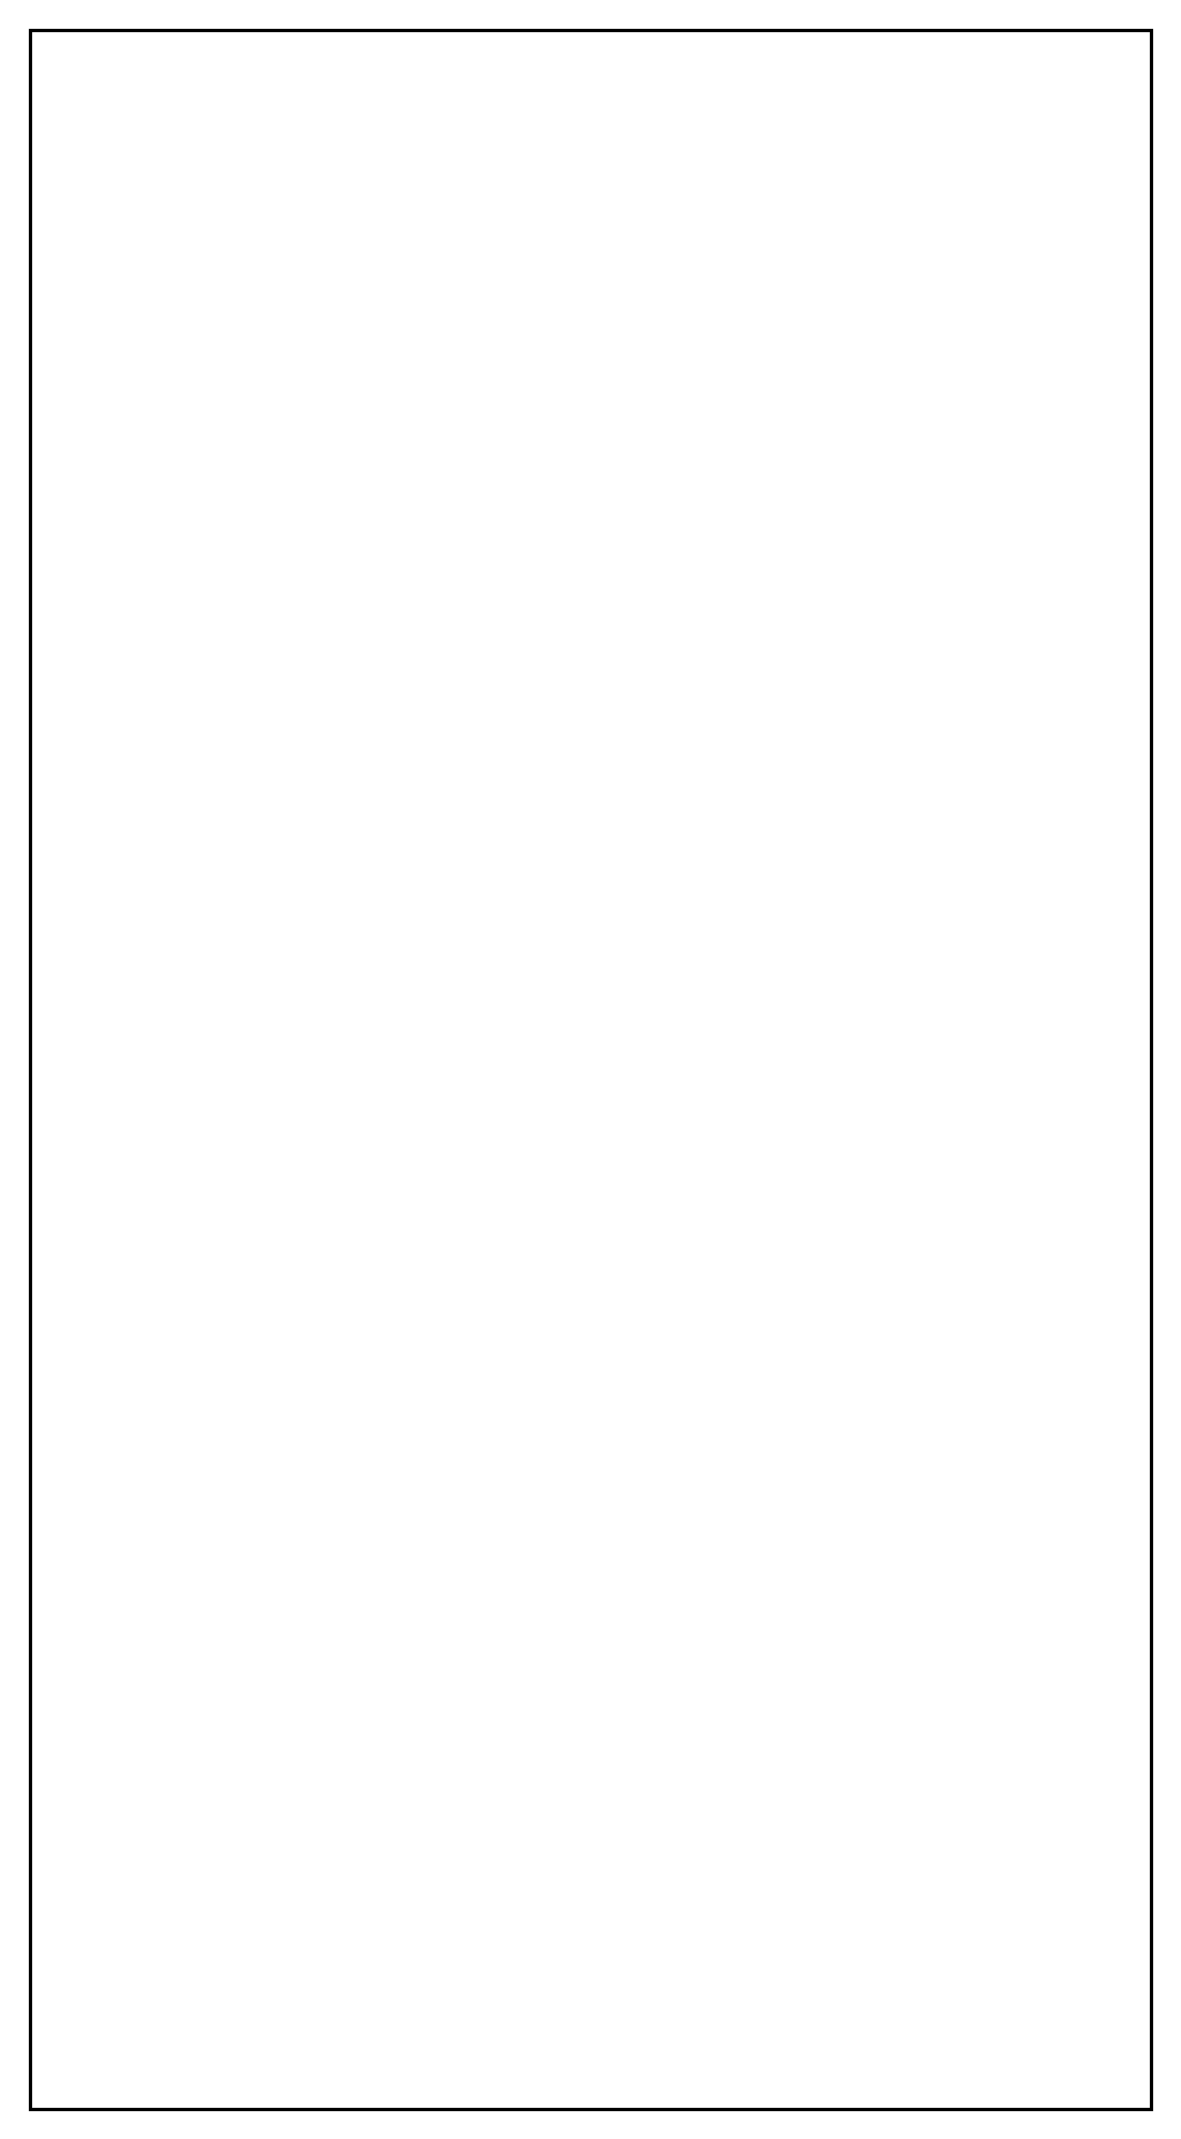

In [4]:
# %% [Run all six requested maps]
run_all_precip_maps()

### Checker: What are highest observed Values in Senorge -> Top Range of Colorbar

#### Highest 1-Day Precip. Value in Senorge

In [13]:
from data_senorge import find_senorge_files, load_senorge_precipitation
import config_paths as cfg
import numpy as np
import pandas as pd

files = find_senorge_files(cfg.SENORGE_RAW_DIR)
year_file = [f for f in files if "2023" in f.name][0]
da = load_senorge_precipitation([year_file])

da = da.rolling(time=1, min_periods=1).sum()
for day in ["2023-08-07","2023-08-08", "2023-08-09"]:
    da_evt = da.sel(time=da.time.dt.date == pd.Timestamp(day).date())
    print(f"  {day}: {float(np.nanmax(da_evt.values)):.1f} mm")

  Opening 1 seNorge files (lazy) ...


/nird/home/lbal/internship_storm_hans/helper/data_senorge.py:57: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/nird/home/lbal/internship_storm_hans/helper/data_senorge.py:57: UserWarning: The specified chunks separate the stored chunks along dimension "X" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


  2023-08-07: 43.7 mm
  2023-08-08: 128.7 mm
  2023-08-09: 149.1 mm


#### Highest 2-Day Precip. Value in Senorge

In [11]:
from data_senorge import find_senorge_files, load_senorge_precipitation
import config_paths as cfg
import numpy as np
import pandas as pd

files = find_senorge_files(cfg.SENORGE_RAW_DIR)
year_file = [f for f in files if "2023" in f.name][0]
da = load_senorge_precipitation([year_file])

da_2day = da.rolling(time=2, min_periods=2).sum()
for day in ["2023-08-07","2023-08-08", "2023-08-09", "2023-08-10"]:
    da_evt = da_2day.sel(time=da_2day.time.dt.date == pd.Timestamp(day).date())
    print(f"  {day}: {float(np.nanmax(da_evt.values)):.1f} mm")

  Opening 1 seNorge files (lazy) ...


/nird/home/lbal/internship_storm_hans/helper/data_senorge.py:57: UserWarning: The specified chunks separate the stored chunks along dimension "Y" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/nird/home/lbal/internship_storm_hans/helper/data_senorge.py:57: UserWarning: The specified chunks separate the stored chunks along dimension "X" starting at index 256. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


  2023-08-07: 99.2 mm
  2023-08-08: 136.0 mm
  2023-08-09: 235.4 mm
  2023-08-10: 177.2 mm
